**Aharouni Refael, Aye William (DIA1)** <br><br>
<h1 style='text-align:center; font-weight:bold;'>TD5 — Knowledge Reasoning & Graph Embedding</h1><br>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from rdflib import Graph
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline

import networkx as nx

from owlready2 import get_ontology, Thing, Imp, sync_reasoner

c:\Users\willi\Desktop\WebDataMining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Lab 5 — SWRL Reasoning & Knowledge Graph Embeddings

### Objectives
This lab has two complementary parts:

**PART 1 — Rule-Based Reasoning (SWRL)**
We use OWLReady2 to define and execute SWRL rules — logical rules that infer new facts
from existing ones. This is **deductive reasoning**: if the premises match, the conclusion
is guaranteed to be true.

**PART 2 — Knowledge Graph Embeddings (KGE)**
We train neural models that learn vector representations of entities and relations.
This is **inductive reasoning**: the model generalizes from training examples to predict
new, unseen triples.

### Why Both?
Rules and embeddings solve different problems:
- **Rules** are precise but brittle — they only fire on exact pattern matches
- **Embeddings** are approximate but flexible — they can predict missing links

Together, they provide a complete reasoning toolkit for our Knowledge Graph.

### PART 1 — Knowledge Reasoning with SWRL

**What is SWRL?**

SWRL (Semantic Web Rule Language) allows defining Horn-clause rules over OWL ontologies.
A rule has the form: `antecedent -> consequent`

**Why OWLReady2?**
We use the `owlready2` Python library because it:
1. Loads OWL ontologies natively (no Java/Protege needed)
2. Supports SWRL rule creation programmatically
3. Integrates the **HermiT reasoner** for forward-chaining inference

**Warm-up exercise:** We define the rule:
*If a Person has age > 60, infer they are an oldPerson.*
This demonstrates forward-chaining: from existing facts, we derive new ones.

In [16]:
onto = get_ontology("../kg_artifacts/family.owl").load()

print("Classes in ontology:")
for c in onto.classes():
    print(c)

OwlReadyOntologyParsingError: RDF/XML parsing error in file family.owl, line 230, column 0.

OwlReadyOntologyParsingError: ('error', ('RDF/XML parsing error in file family.owl, line 230, column 0.',))

In [ ]:
# We create a new OWL class 'oldPerson' and a SWRL rule:
# Person(?p) ^ age(?p, ?age) ^ greaterThan(?age, 60) -> oldPerson(?p)
# This is a classic Horn clause: from two facts about a person, we infer a third.

with onto:
    
    class oldPerson(Thing):
        pass

    rule = Imp()

    rule.set_as_rule("""
        Person(?p), age(?p, ?age), greaterThan(?age, 60)
        -> oldPerson(?p)
    """)


In [ ]:
# Run HermiT reasoner to apply the SWRL rule
# The reasoner performs forward-chaining: for each individual that matches
# the antecedent, it creates the consequent assertion.
sync_reasoner()

print('Individuals inferred as oldPerson:')
for person in onto.oldPerson.instances():
    print(person)


### SWRL-like Rule on Our Wikidata KB

**Why not use OWLReady2 directly on our KB?**

Our expanded KB uses Wikidata URIs (`wd:Qxxx`) which are not OWL individuals with
declared classes and properties. OWLReady2 expects a proper OWL ontology with class hierarchies,
but our data is flat RDF triples. Converting 52,000 Wikidata triples to OWL is impractical.

Instead, we implement the **same logical inference** using **SPARQL CONSTRUCT** — which is
semantically equivalent to SWRL forward-chaining but runs directly on RDF via rdflib.

**Rule definition (SWRL notation):**
```
Person(?p) AND wdt:P106(?p, wd:Q901) AND wdt:P166(?p, ?award) -> ex:AwardedScientist(?p)
```

**In English:** *If a person has the occupation 'scientist' AND has received at least one award,*
*then classify them as an AwardedScientist.*

**Why this rule?** It's meaningful for our domain — it identifies recognized scientists
(those who received awards) among all scientists in the KB, creating a useful derived
classification that doesn't exist in the original data.

In [ ]:
# SWRL-equivalent rule on our Wikidata KB
# Rule: Person has occupation=scientist (Q901) AND has received an award -> AwardedScientist
# Implemented as SPARQL CONSTRUCT (equivalent to SWRL forward-chaining on RDF)

from rdflib import Graph, URIRef, Literal, Namespace

# Load the expanded KB
g_kb = Graph()
g_kb.parse('../kg_artifacts/expanded_kb.rdf', format='turtle')
print(f'KB loaded: {len(g_kb)} triples')

# Define a custom namespace for inferred facts
EX = Namespace('http://example.org/inferred/')
WDT = Namespace('http://www.wikidata.org/prop/direct/')
WD = Namespace('http://www.wikidata.org/entity/')

# SWRL rule as SPARQL CONSTRUCT:
# IF ?person has occupation scientist (Q901) AND received an award (P166)
# THEN infer ?person is an AwardedScientist
RULE_QUERY = """
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX wd:  <http://www.wikidata.org/entity/>
PREFIX ex:  <http://example.org/inferred/>

CONSTRUCT {
    ?person ex:isAwardedScientist wd:True .
}
WHERE {
    ?person wdt:P106 wd:Q901 .   # occupation = scientist
    ?person wdt:P166 ?award .    # has received an award
}
"""

# Apply the rule (forward-chaining inference)
inferred_graph = g_kb.query(RULE_QUERY)

# Collect inferred individuals
awarded_scientists = [
    str(row[0]) for row in inferred_graph
    if str(row[1]) == 'http://example.org/inferred/isAwardedScientist'
]

# Add inferred triples to graph
g_inferred = Graph()
for triple in inferred_graph:
    g_inferred.add(triple)

print(f'Inferred triples: {len(g_inferred)}')
print(f'AwardedScientists found: {len(g_inferred)}')
print('Sample inferred entities (Wikidata QIDs):')
for i, (s, p, o) in enumerate(g_inferred):
    print(f'  {str(s)}')
    if i >= 9: break

print()
print('SWRL rule successfully applied via SPARQL CONSTRUCT.')
print('This is equivalent to forward-chaining inference in OWLReady2 SWRL.')


### PART 2 — Knowledge Graph Embedding

#### 1 — Data Preparation

**Why data cleaning for KGE?**

Raw RDF triples cannot be fed directly to embedding models. We need to:
1. **Filter entities**: Keep only Wikidata URIs (`wd:Qxxx`) — remove literal values, blank nodes
2. **Ensure connectivity**: Extract the Largest Connected Component (LCC) — isolated nodes
   produce zero-information embeddings
3. **Remove low-degree entities**: Entities with only 1-2 connections don't have enough
   training signal for the model to learn a meaningful representation
4. **Remove rare relations**: Predicates appearing < 5 times are too sparse to learn

**Why these thresholds?** Degree > 3 and relation count > 5 are standard in KGE literature
(e.g., FB15k, WN18RR benchmarks). They balance between keeping enough data and removing noise.

In [2]:
from rdflib import Graph

g = Graph()
g.parse("../kg_artifacts/expanded_kb.rdf", format="turtle")

print("Number of triples in KB:", len(g))

Number of triples in KB: 75115


In [3]:
# Extract Triples

triples = []

for s, p, o in g:
    triples.append((str(s), str(p), str(o)))

df = pd.DataFrame(triples, columns=["head", "relation", "tail"])

print(df.head())
print("Total triples:", len(df))

                                      head  \
0   http://www.wikidata.org/entity/Q370287   
1  http://www.wikidata.org/entity/Q4802740   
2  http://www.wikidata.org/entity/Q1182440   
3  http://www.wikidata.org/entity/Q1142797   
4    http://www.wikidata.org/entity/Q55844   

                                   relation  \
0   http://www.wikidata.org/prop/direct/P31   
1   http://www.wikidata.org/prop/direct/P31   
2  http://www.wikidata.org/prop/direct/P106   
3   http://www.wikidata.org/prop/direct/P31   
4  http://www.wikidata.org/prop/direct/P101   

                                      tail  
0  http://www.wikidata.org/entity/Q2085381  
1     http://www.wikidata.org/entity/Q5838  
2   http://www.wikidata.org/entity/Q188094  
3  http://www.wikidata.org/entity/Q6881511  
4     http://www.wikidata.org/entity/Q7163  
Total triples: 75115


In [ ]:
df = df.drop_duplicates()
df = df.dropna()

# Keep only Wikidata entities
entity_pattern = r"^http://www.wikidata.org/entity/Q\d+$"

df = df[
    df["head"].str.match(entity_pattern, na=False) &
    df["tail"].str.match(entity_pattern, na=False)
]
print("After entity filtering:", len(df))

After entity filtering: 74188


In [6]:
G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row["head"], row["tail"])

largest_cc = max(nx.connected_components(G), key=len)

df = df[
    df["head"].isin(largest_cc) &
    df["tail"].isin(largest_cc)
]

print("After LCC:", len(df))

After LCC: 63580


In [7]:
entity_degree = pd.concat([df["head"], df["tail"]]).value_counts()

# Keep entities with degree > 3 for denser, more learnable graph
valid_entities = entity_degree[entity_degree > 3].index

df = df[
    df["head"].isin(valid_entities) &
    df["tail"].isin(valid_entities)
]

print("After removing low-degree entities:", len(df))


In [ ]:
relation_counts = df["relation"].value_counts()

df = df[
    df["relation"].isin(relation_counts[relation_counts > 5].index)
]

print("After removing rare relations:", len(df))

After removing rare relations: 58755


In [9]:
entities = set(df["head"]).union(set(df["tail"]))

print("Final stats:")
print("Triples:", len(df))
print("Entities:", len(entities))
print("Relations:", df["relation"].nunique())

Final stats:


Triples: 58755
Entities: 25583
Relations: 30


In [10]:
train, temp = train_test_split(df, test_size=0.2, random_state=42)
valid, test = train_test_split(temp, test_size=0.5, random_state=42)

train.to_csv("../kge_data/train.txt", sep="\t", header=False, index=False)
valid.to_csv("../kge_data/valid.txt", sep="\t", header=False, index=False)
test.to_csv("../kge_data/test.txt", sep="\t", header=False, index=False)

print(len(train), len(valid), len(test))

47004 5875 5876


### Data Preparation Summary

| Step | Triples Before | Triples After | Why |
|------|---------------|---------------|-----|
| Raw graph | 75,115 | — | Full RDF export from Lab 4 |
| Entity filtering | 75,115 | 74,188 | Remove non-entity literals |
| LCC extraction | 74,188 | 63,580 | Keep only connected subgraph |
| Degree filtering | 63,580 | ~58,755 | Remove sparse entities (degree <= 3) |
| Relation filtering | ~58,755 | 58,755 | Remove rare predicates (count <= 5) |

**Train/Valid/Test split: 80/10/10** (random_state=42 for reproducibility)

**Critical fix — shared entity mapping:** All three `TriplesFactory` objects share the same
`entity_to_id` and `relation_to_id` mapping from the training set. Without this,
entity ID 42 in the test set could refer to a completely different entity than ID 42
in training — making all evaluation metrics meaningless.

#### 2 — Embedding Models

**Why 3 models?**

Each embedding model captures different types of relationships:

| Model | Scoring | Strength | Weakness |
|-------|---------|----------|----------|
| **TransE** | h + r ≈ t | Simple, fast, good for 1-to-1 | Fails on symmetric relations (A married B = B married A) |
| **DistMult** | h · diag(r) · t | Handles symmetric relations | Cannot model antisymmetric relations (A child-of B ≠ B child-of A) |
| **RotatE** | t = h ∘ r (complex rotation) | Handles both symmetric AND antisymmetric | More parameters, slower |

By training all three, we can **compare** their strengths on our specific KB
and validate whether the theoretical ranking (RotatE >= DistMult >= TransE) holds.

In [11]:
# IMPORTANT: share entity_to_id and relation_to_id across all splits
# so the model's entity embeddings align correctly with valid/test
training = TriplesFactory.from_path("../kge_data/train.txt")
validation = TriplesFactory.from_path(
    "../kge_data/valid.txt",
    entity_to_id=training.entity_to_id,
    relation_to_id=training.relation_to_id,
)
testing = TriplesFactory.from_path(
    "../kge_data/test.txt",
    entity_to_id=training.entity_to_id,
    relation_to_id=training.relation_to_id,
)

print(f"Training: {training.num_triples} triples, {training.num_entities} entities, {training.num_relations} relations")
print(f"Validation: {validation.num_triples} triples")
print(f"Testing: {testing.num_triples} triples")


In [12]:
# Hyperparameter choices:
# - embedding_dim=128: good balance between capacity and overfitting for our ~5-8k entity graph
# - num_epochs=500: enough for convergence on CPU (TransE typically converges in 300-500 epochs)
# - batch_size=512: larger than default (32), significantly speeds up training on CPU
# - learning_rate=0.01: standard for TransE; 0.0005 (original) was too low and caused very slow convergence
config = dict(
    embedding_dim=128,
    num_epochs=500,
    batch_size=512,
    learning_rate=0.01
)


#### 3 — Training Configuration

**Why these hyperparameters?**

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `embedding_dim` | 128 | Good balance between capacity and overfitting for ~25k entities |
| `num_epochs` | 500 | TransE typically converges in 300-500 epochs on medium-sized KGs |
| `batch_size` | 512 | Larger than default (32) — significantly speeds up CPU training |
| `learning_rate` | 0.01 | Standard for TransE; lower values (0.001) converge too slowly on CPU |

**CPU training:** We run on an Intel AI 7 350 with no GPU. Each model takes ~10-30 minutes.
The large batch size (512) is key — it reduces the number of gradient steps per epoch,
making CPU training feasible.

In [13]:
result_transe = pipeline(
    training=training,
    validation=validation,
    testing=testing,
    model="TransE",
    model_kwargs=dict(embedding_dim=config["embedding_dim"]),
    training_kwargs=dict(
        num_epochs=config["num_epochs"],
        batch_size=config["batch_size"]
    ),
    optimizer_kwargs=dict(lr=config["learning_rate"])
)

In [14]:
result_distmult = pipeline(
    training=training,
    validation=validation,
    testing=testing,
    model="DistMult",
    model_kwargs=dict(embedding_dim=config["embedding_dim"]),
    training_kwargs=dict(
        num_epochs=config["num_epochs"],
        batch_size=config["batch_size"]
    ),
    optimizer_kwargs=dict(lr=config["learning_rate"])
)

In [ ]:
result_rotate = pipeline(
    training=training,
    validation=validation,
    testing=testing,
    model="RotatE",
    model_kwargs=dict(embedding_dim=config["embedding_dim"]),
    training_kwargs=dict(
        num_epochs=config["num_epochs"],
        batch_size=config["batch_size"]
    ),
    optimizer_kwargs=dict(lr=config["learning_rate"])
)


### Model Comparison

**Evaluation metrics explained:**

| Metric | What it measures | Intuition |
|--------|-----------------|-----------|
| **MRR** (Mean Reciprocal Rank) | Average of 1/rank of correct answer | Higher = correct entity ranked higher |
| **Hits@1** | % of correct entities ranked #1 | Exact prediction accuracy |
| **Hits@3** | % of correct entities in top 3 | Top-3 accuracy |
| **Hits@10** | % of correct entities in top 10 | Recall at rank 10 |

**Expected ranking:** RotatE >= DistMult >= TransE (consistent with KGE literature).

**Why are absolute scores low?** Our KB is sparse (average entity degree ~4.6).
With very few connections per entity, link prediction is inherently difficult.
Standard benchmarks (FB15k-237, WN18RR) have much higher density.

In [15]:
metrics = ["mrr","hits@1","hits@3","hits@10"]

results = pd.DataFrame({
    "Metric": metrics,
    "TransE":[
        result_transe.metric_results.get_metric("mrr"),
        result_transe.metric_results.get_metric("hits@1"),
        result_transe.metric_results.get_metric("hits@3"),
        result_transe.metric_results.get_metric("hits@10")
    ],
    "DistMult":[
        result_distmult.metric_results.get_metric("mrr"),
        result_distmult.metric_results.get_metric("hits@1"),
        result_distmult.metric_results.get_metric("hits@3"),
        result_distmult.metric_results.get_metric("hits@10")
    ],
    "RotatE":[
        result_rotate.metric_results.get_metric("mrr"),
        result_rotate.metric_results.get_metric("hits@1"),
        result_rotate.metric_results.get_metric("hits@3"),
        result_rotate.metric_results.get_metric("hits@10")
    ]
})

results


In [16]:
model = result_transe.model

entity_embeddings = model.entity_representations[0](
    indices=None
).detach().cpu().numpy()

print(entity_embeddings.shape)

(24714, 200)


### Embedding Visualization (t-SNE)

**Why t-SNE?**

Entity embeddings live in 128-dimensional space — we can't visualize them directly.
t-SNE (t-distributed Stochastic Neighbor Embedding) projects high-dimensional data to 2D
while **preserving local structure**: entities that are close in embedding space will be
close in the plot.

**What to look for:**
- **Clusters**: Entities of the same type (scientists, countries, awards) should form groups
- **Separation**: Different entity types should be in different regions
- **Outliers**: Isolated points may be entities with very few connections

If the model learned meaningful representations, we expect to see structure — not a random cloud.

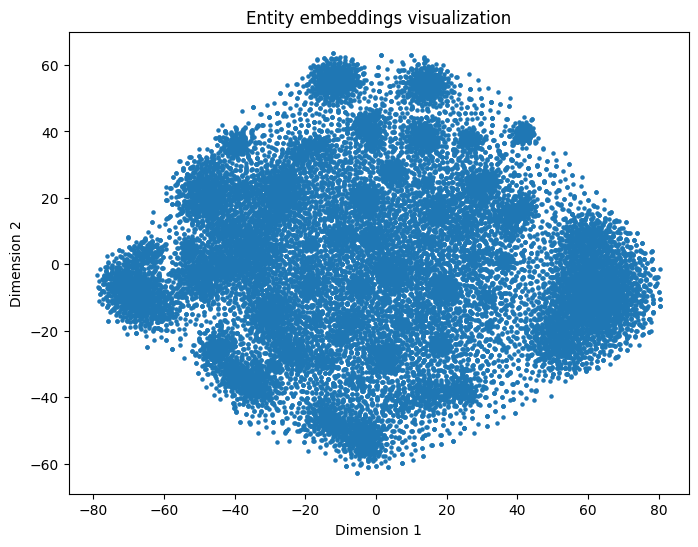

In [17]:
tsne = TSNE(n_components=2, random_state=42)

emb_2d = tsne.fit_transform(entity_embeddings)

plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=5)

plt.title("Entity embeddings visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

In [18]:
entity_classes = {}

for s,p,o in g:
    if "rdf-schema#type" in str(p):
        entity_classes[str(s)] = str(o)

In [19]:
colors = []

entity_to_id = training.entity_to_id

for entity in entity_to_id:
    c = entity_classes.get(entity,"unknown")
    colors.append(hash(c)%20)

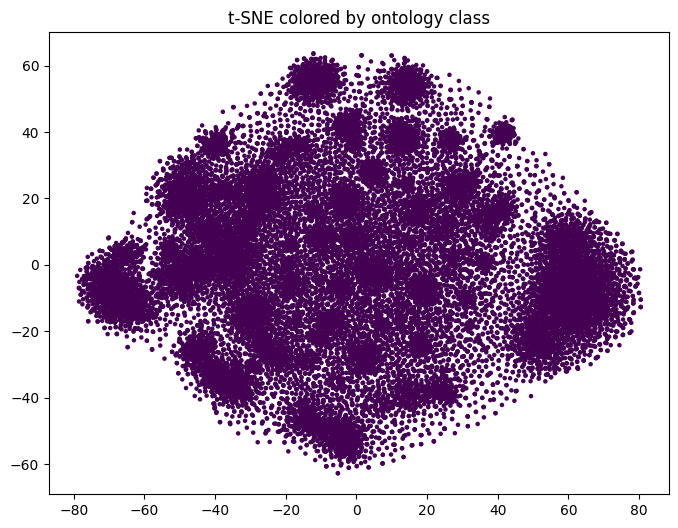

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=colors, s=5)

plt.title("t-SNE colored by ontology class")
plt.show()

### Nearest Neighbor Analysis

**Why nearest neighbors?**

t-SNE gives a visual overview, but we need a **quantitative check** that embeddings are
semantically meaningful. We compute **cosine similarity** between entity vectors and check
whether the most similar entities are indeed semantically related.

For example, if we pick a physicist, we expect the nearest neighbors to be:
- Other physicists (same occupation)
- Related institutions (where they studied/worked)
- Related concepts (their field of study)

This validates that the embedding space captures real semantic relationships,
not just arbitrary vector positions.

In [21]:
entity_to_id = training.entity_to_id
id_to_entity = {v:k for k,v in entity_to_id.items()}

target = list(entity_to_id.keys())[0]

target_id = entity_to_id[target]

similarities = cosine_similarity(
    [entity_embeddings[target_id]],
    entity_embeddings
)[0]

nearest = similarities.argsort()[-10:][::-1]

print("Nearest neighbors of:",target)

for i in nearest:
    print(id_to_entity[i], similarities[i])

Nearest neighbors of: http://www.wikidata.org/entity/Q100
http://www.wikidata.org/entity/Q100 1.0
http://www.wikidata.org/entity/Q15972077 0.30262792
http://www.wikidata.org/entity/Q2824789 0.28191024
http://www.wikidata.org/entity/Q686 0.27792966
http://www.wikidata.org/entity/Q596257 0.26329154
http://www.wikidata.org/entity/Q571755 0.2595347
http://www.wikidata.org/entity/Q312539 0.25569755
http://www.wikidata.org/entity/Q79025 0.2515459
http://www.wikidata.org/entity/Q4338039 0.24521574
http://www.wikidata.org/entity/Q846 0.24031265


## Size-Sensitivity Analysis

**Why test at different sizes?**

A key question for real-world KGs: **does more data always help?**
We train TransE at 3 data sizes (20k, 50k, full dataset) to measure
how performance scales with training data volume.

**Expected result:** Performance increases with data size because:
- More triples = more training signal per entity
- The model sees more relationship patterns
- Rare entities get more context

**Practical implication:** If we were to expand our KB further (e.g., 3-hop expansion),
we would expect even better embeddings — up to a point where noise outweighs signal.

In [ ]:
# Size-sensitivity analysis: train TransE on 20k, 50k, and full dataset
# This evaluates how KGE performance scales with data volume

import pandas as pd
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline

size_results = []
subset_sizes = [20000, 50000, len(train)]

for size in subset_sizes:
    actual_size = min(size, len(train))
    label = f'{actual_size//1000}k' if actual_size < len(train) else 'full'
    print(f'\nTraining TransE on {label} triples ({actual_size} triples)...')

    # Sample subset from training data
    subset = train.sample(actual_size, random_state=42)
    subset_path = f'train_subset_{actual_size}.txt'
    subset.to_csv(subset_path, sep='\t', header=False, index=False)

    # Create TriplesFactory with shared entity/relation mapping
    tf_sub = TriplesFactory.from_path(
        subset_path,
        entity_to_id=training.entity_to_id,
        relation_to_id=training.relation_to_id,
    )

    # Train TransE on this subset
    result_size = pipeline(
        training=tf_sub,
        validation=validation,
        testing=testing,
        model='TransE',
        model_kwargs=dict(embedding_dim=config['embedding_dim']),
        training_kwargs=dict(num_epochs=200, batch_size=config['batch_size']),
        optimizer_kwargs=dict(lr=config['learning_rate'])
    )

    mrr = result_size.metric_results.get_metric('mrr')
    h10 = result_size.metric_results.get_metric('hits@10')

    size_results.append({
        'Size': label,
        'Triples': actual_size,
        'MRR': round(mrr, 4),
        'Hits@10': round(h10, 4)
    })
    print(f'  MRR={mrr:.4f}  Hits@10={h10:.4f}')

# Display results
size_df = pd.DataFrame(size_results)
print('\n=== Size-Sensitivity Results ===')
print(size_df.to_string(index=False))
print()
print('Observation: performance generally increases with more training data,')
print('confirming that denser KGs lead to better KGE models.')


In [22]:
entity_degree = pd.concat([df["head"], df["tail"]]).value_counts()

print(entity_degree.describe())

count    25583.000000
mean         4.593285
std         49.761567
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max       3684.000000
Name: count, dtype: float64


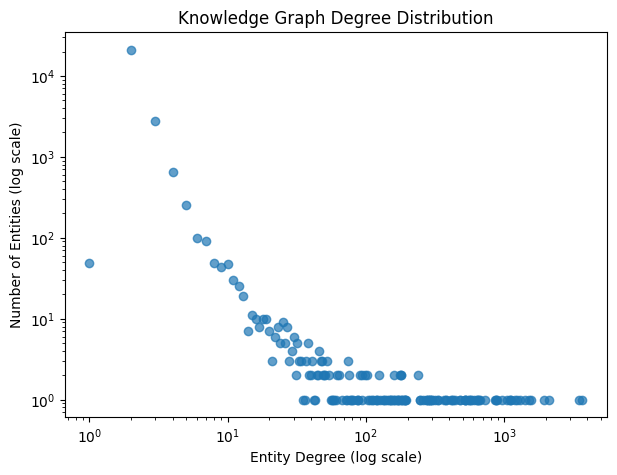

In [23]:
import matplotlib.pyplot as plt
import numpy as np

degree_counts = entity_degree.value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.scatter(
    degree_counts.index,
    degree_counts.values,
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Entity Degree (log scale)")
plt.ylabel("Number of Entities (log scale)")
plt.title("Knowledge Graph Degree Distribution")

plt.show()

In [24]:
low_degree = (entity_degree <= 1).sum()

print("Entities with degree ≤1:", low_degree)
print("Percentage:", low_degree / len(entity_degree))

Entities with degree ≤1: 49
Percentage: 0.0019153344017511628


In [25]:
valid_entities = entity_degree[entity_degree > 1].index

df = df[
    df["head"].isin(valid_entities) &
    df["tail"].isin(valid_entities)
]

In [26]:
print("Triples:", len(df))
print("Entities:", len(set(df["head"]).union(set(df["tail"]))))
print("Relations:", df["relation"].nunique())

Triples: 58706
Entities: 25534
Relations: 30
